In [12]:
import pandas as pd

In [13]:
dados = pd.read_csv('https://raw.githubusercontent.com/LuizinhoXT/Python/refs/heads/main/machine_learning/nlp_machine_learning/dataset_avaliacoes.csv')

In [14]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [15]:
dados.value_counts('sentimento')

sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

In [16]:
print('positivo \n\n', dados.avaliacao[0])

positivo 

 Esse smartphone superou minhas expectativas, recomendo


In [17]:
print('negativo \n\n', dados.avaliacao[1])

negativo 

 o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

In [19]:
# teste de vetorização para entender o funcionamento do algoritimo

texto = ['Esse smartphone superou minhas expectativas, recomendo', 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [20]:
# Matrix esparsa é o retorno de bag_of_words que acontece quando temos vários 0's dentro de uma matriz
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 15 stored elements and shape (2, 15)>

In [21]:
# Através da vetorização, criamos uma tabela em que os elementos escalam de maneira horizontal, gerando assim uma classificação binária que avalia se determinada palavra existe ou não exister em determinado registro de dados.

matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag_of_words,columns=vetorizar.get_feature_names_out())

matriz_esparsa

,cheiro,desagradavel,esse,expectativas,incomoda,minhas,muito,nao,pra,quem,recomendo,recomendoo,se,smartphone,superou
0,0,0,1,1,0,1,0,0,0,0,1,0,0,1,1
1,1,1,0,0,1,0,1,1,1,1,0,1,1,0,0


In [22]:
# A dimensão na pós vetorização aumenta horizontalmente e isso se mostra no Output dessa célula com +23k de colunas.
# Isso é um problema pois é computacionalmente caro

vetorizar = CountVectorizer(lowercase=False)

bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

(15501, 23352)


In [23]:
# Otimizando o código para limitar a quantidade de features geradas pela vetorização


vetorizar = CountVectorizer(lowercase=False, max_features=50)

bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

# A limitação de features considera as palavras que tem maior ocorrencia dentro da dos dados


(15501, 50)


In [24]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns= vetorizar.get_feature_names_out())
matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
# Separação em treino teste split
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, dados.sentimento, random_state=4978)

In [26]:
# Aplicando algorítmo de Regressão Logística 
from sklearn.linear_model import LogisticRegression

regresssao_logistica = LogisticRegression()
regresssao_logistica.fit(x_treino, y_treino)
acuracia = regresssao_logistica.score(x_teste, y_teste)
acuracia

0.7982456140350878

- Crie uma função chamada classificar_texto, que aceite três parâmetros: o nome do DataFrame, o nome da coluna contendo as avaliações de texto e o nome da coluna correspondente aos sentimentos;
- Utilize a classe CountVectorizer para transformar o texto em um vetor bag of words, com um número máximo de 50 features;
- Separe os dados em conjuntos de treino e teste utilizando train_test_split;
- Crie um modelo de regressão logística e ajuste-o aos dados de treino;
- Calcule e retorne a acurácia do modelo para os dados de teste;
- Retorne o valor da acurácia.

In [27]:
def classificar_texto(df,col_ava_texto, sentimento):
    
    from sklearn.feature_extraction.text import CountVectorizer
    
    vetorizar = CountVectorizer(lowercase=False, max_features=50)

    bag_of_words = vetorizar.fit_transform(df[col_ava_texto])
    print(bag_of_words.shape)

    from sklearn.model_selection import train_test_split

    x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, dados[sentimento], random_state=4978)
    
    from sklearn.linear_model import LogisticRegression

    regresssao_logistica = LogisticRegression()
    regresssao_logistica.fit(x_treino, y_treino)
    acuracia = regresssao_logistica.score(x_teste, y_teste)
   
    return print(f"\nAcurácia do modelo com a coluna '{col_ava_texto}': {acuracia * 100:.2f}%")

# Essa fuinção facilita o processo de classificação do texto, prevendo futuras avaliações


In [28]:
classificar_texto(dados,'avaliacao','sentimento')


(15501, 50)

Acurácia do modelo com a coluna 'avaliacao': 79.82%


#### Resumo até aqui

- Explorar dados textuais;
- Utilizar a técnica de Bag of words para converter textos em vetores numéricos;
- Separar os dados em treino e teste;
- Treinar o modelo de regressão logística;
- Obter a acurácia do modelo nos dados de teste.

In [29]:
! pip install wordcloud
from wordcloud import WordCloud

In [30]:
todas_palavras = [texto for texto in dados.avaliacao]
todas_palavras

['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [31]:
todas_palavras = ' '.join([texto for texto in dados.avaliacao])
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [32]:
nuvem_palavras = WordCloud().generate(todas_palavras)

<function matplotlib.pyplot.show(close=None, block=None)>

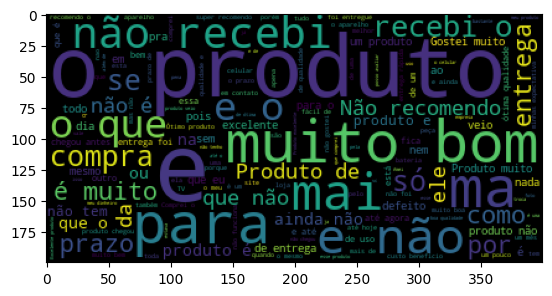

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(nuvem_palavras)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

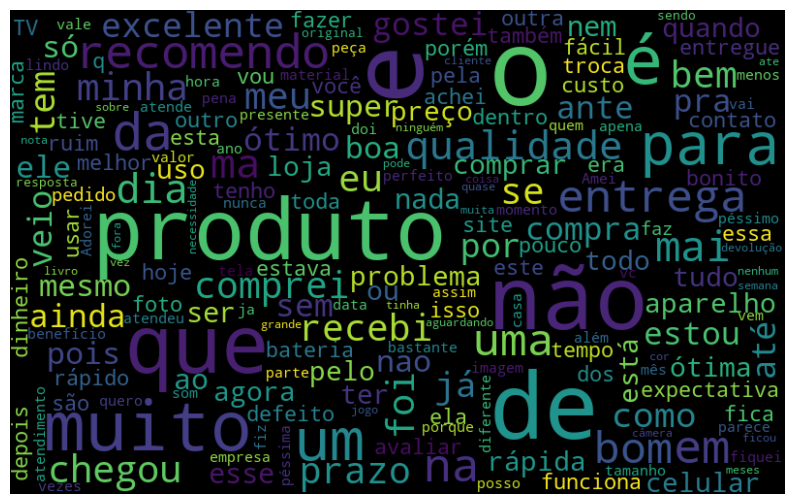

In [34]:
import matplotlib.pyplot as plt

novo_nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110, collocations=False).generate(todas_palavras)

plt.figure(figsize=(10,7))
plt.imshow(novo_nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show

In [35]:
def nuvem_palavras(dados,col_texto,sentimento):
    texto_sentimento = dados.query(f"sentimento == '{sentimento}'")[col_texto]

    texto_unido = ''.join(texto_sentimento)

    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110, collocations=False).generate(texto_unido)
    plt.figure(figsize=(10,7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis('off')
    plt.show

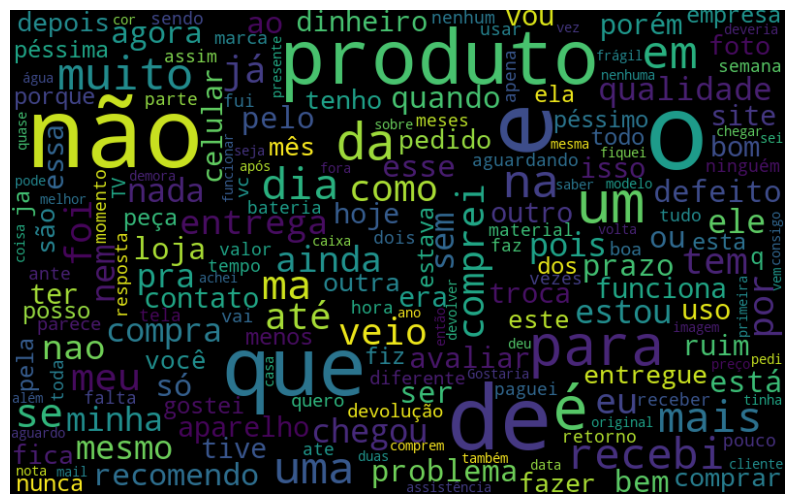

In [36]:
nuvem_palavras(dados,'avaliacao','negativo')

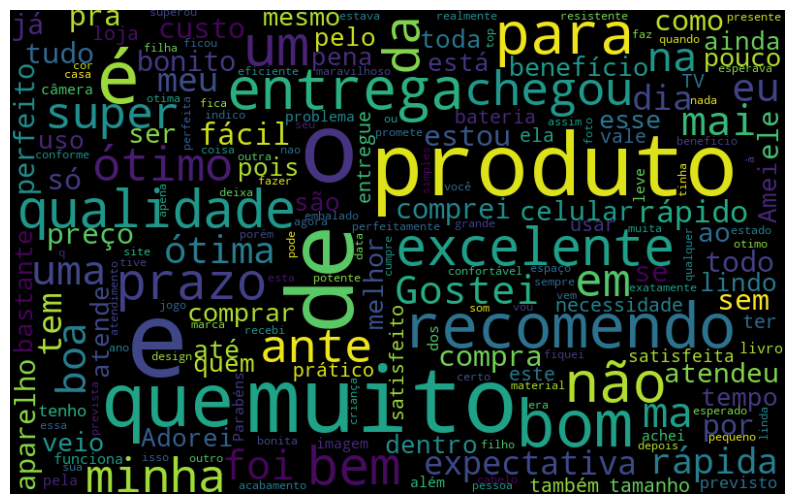

In [37]:
nuvem_palavras(dados,'avaliacao','positivo')

In [38]:
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [39]:
! pip install nltk



In [40]:
import nltk

In [41]:
frases = ['um produto bom', 'um produto ruim']

In [42]:
frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'um produto bom': 1, 'um produto ruim': 1})

In [43]:
# Aplicando o processo de tokenização que irá separar o texto em palavras menores

from nltk import tokenize

frase = 'o produto é excelente e a entrega foi muita rápida!'
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
print(token_frase)

['o', 'produto', 'é', 'excelente', 'e', 'a', 'entrega', 'foi', 'muita', 'rápida!']


In [44]:
token_frase = token_espaco.tokenize(todas_palavras)
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [45]:
df_frequencia = pd.DataFrame({'palavra':list(frequencia.keys()),
                              'frequencia':list(frequencia.values())})

In [46]:
df_frequencia.head()

,palavra,frequencia
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


In [47]:
df_frequencia.nlargest(columns='frequencia',n=10)


,palavra,frequencia
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


[Text(0, 0.5, 'Contagem')]

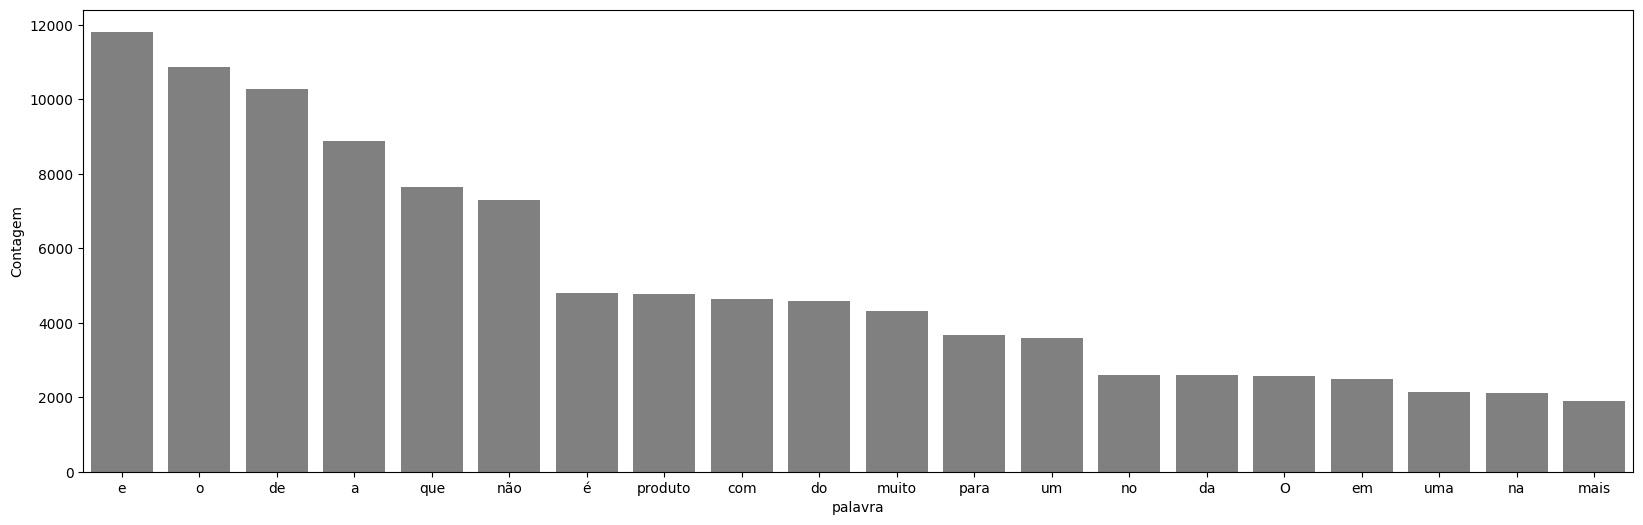

In [48]:
import seaborn as sns

plt.figure(figsize=(20,6))
ax = sns.barplot(df_frequencia.nlargest(columns='frequencia',n=20), x='palavra', y='frequencia',color='grey')
ax.set(ylabel='Contagem')

- Receba três parâmetros: o nome do DataFrame contendo a coluna com o texto, o nome da coluna de texto e a quantidade de palavras mais frequentes a serem exibidas;
- Concatene todas as palavras presentes em uma determinada coluna de um DataFrame;
- Calcule a frequência de cada palavra usando a biblioteca NLTK;
- Converta os resultados em um DataFrame contendo duas colunas: "Palavra" e "Frequência";
- Selecione as palavras mais frequentes, de acordo com a quantidade especificada pelo usuário;
- Plote um gráfico de barras exibindo a frequência dessas palavras utilizando a biblioteca seaborn.

In [49]:
def grafico_frequencia(df,nm_col_ava,qty):

    todas_palavras = ' '.join([texto for texto in df[nm_col_ava]])
    token_frase = token_espaco.tokenize(todas_palavras)
    frequencia = nltk.FreqDist(token_frase)

    df_frequencia = pd.DataFrame({'palavra':list(frequencia.keys()),
                              'frequencia':list(frequencia.values())})
    
    plt.figure(figsize=(20,6))
    ax = sns.barplot(df_frequencia.nlargest(columns='frequencia',n=qty), x='palavra', y='frequencia',color='grey')
    ax.set(ylabel='Contagem')


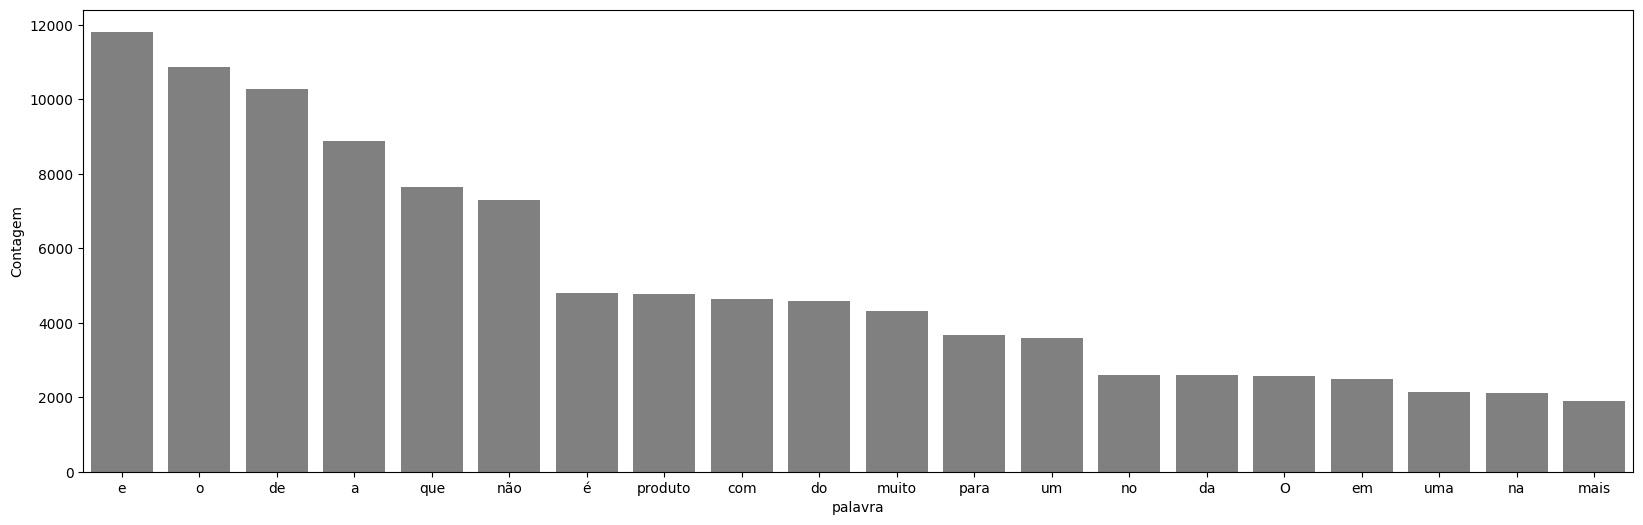

In [50]:
grafico_frequencia(dados,'avaliacao',20)

- Utilizar a biblioteca wordcloud para criar nuvens de palavras;
- Criar uma função para filtrar os sentimentos;
- Aplicar a tokenização com a biblioteca NLTK;
- Calcular a frequência das palavras com a biblioteca NLTK;
- Criar um gráfico com as palavras mais frequentes.

In [ ]:
# A biblioteca Nlkt ajuda a criar uma lista de palavras de baixo valor semântico, que depois será utilizada para filtrar os dados do data frame

import nltk

nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\luizf\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       tagge

True

In [51]:
# Já possui um módulo que mapeia as palavras mais comuns da lingua portuguesa. A bibliotera também possue outras idiomas padrão.
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

In [ ]:
# Algoritmo de filtragem de stopwords

def filtro_stopword(df,nm_col_texto):
    palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_espaco = tokenize.WhitespaceTokenizer() # instancia do tokenizaddor

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_espaco.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [palavra for palavra in token_palavras if palavra not in palavras_irrelevantes] # sub-laço for filtrando as palavras que não devem estar no final
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos daod processados

In [53]:
dados['tratamento_1'] = filtro_stopword(dados,'avaliacao')

In [54]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo"
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo..."


In [55]:
dados["avaliacao"][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [56]:
dados['tratamento_1'][1]

'cheiro desagradavel!! pra incomoda nao recomendoo..'

In [57]:
dados['avaliacao'][2]


'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

In [58]:
dados['tratamento_1'][2]


'Eu fiz compra loja entregou produto, compra feita cartão credito ate momento loja nao devolveu valor compra.'

In [59]:
classificar_texto(dados,'tratamento_1','sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_1': 81.09%


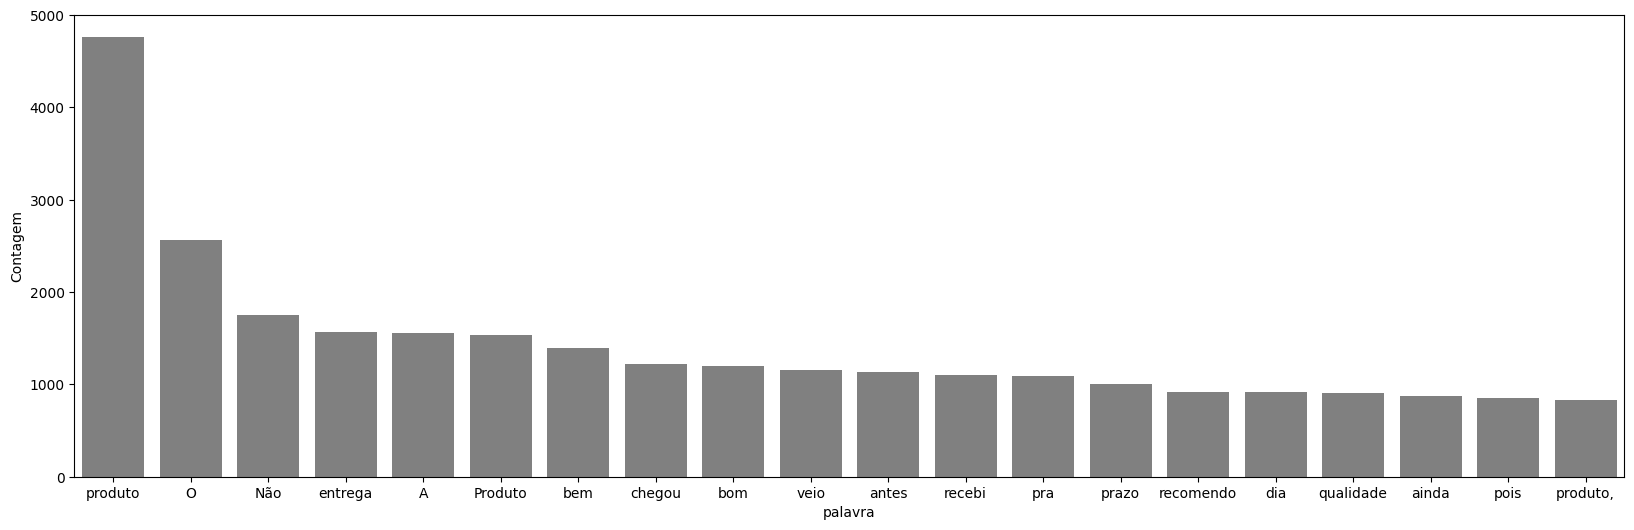

In [60]:
grafico_frequencia(dados,'tratamento_1',20)

In [66]:
frase = 'Esse smartphone superou minhas expectativas, recomendo!'

In [67]:

token_pontuacao = tokenize.WordPunctTokenizer()
token_frase = token_pontuacao.tokenize(frase)
token_frase

['Esse',
 'smartphone',
 'superou',
 'minhas',
 'expectativas',
 ',',
 'recomendo',
 '!']

In [ ]:
# Algoritmo de filtragem de stopwords

def filtro_alfanumerico_stopword(df,nm_col_texto):
    palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_pontuacao = tokenize.WordPunctTokenizer() # instancia do tokenizador que também separa em tokensm tudo que é alfánumérico incluíndo potuações

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_pontuacao.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [palavra for palavra in token_palavras if palavra.isalpha() and palavra not in palavras_irrelevantes] # sub-laço for filtrando as palavras que não devem estar processamento final e eliminando os caracteres alfanuméricos
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos daod processados

In [99]:
dados['tratamento_2'] = filtro_alfanumerico_stopword(dados,'tratamento_1')

In [101]:
dados['tratamento_2'][10]

'Melhor esperado cor maravilhosa Recomendo Deixa ambiente moderno'

In [102]:
dados['tratamento_1'][10]

'Melhor esperado, cor maravilhosa! Recomendo. Deixa ambiente moderno'

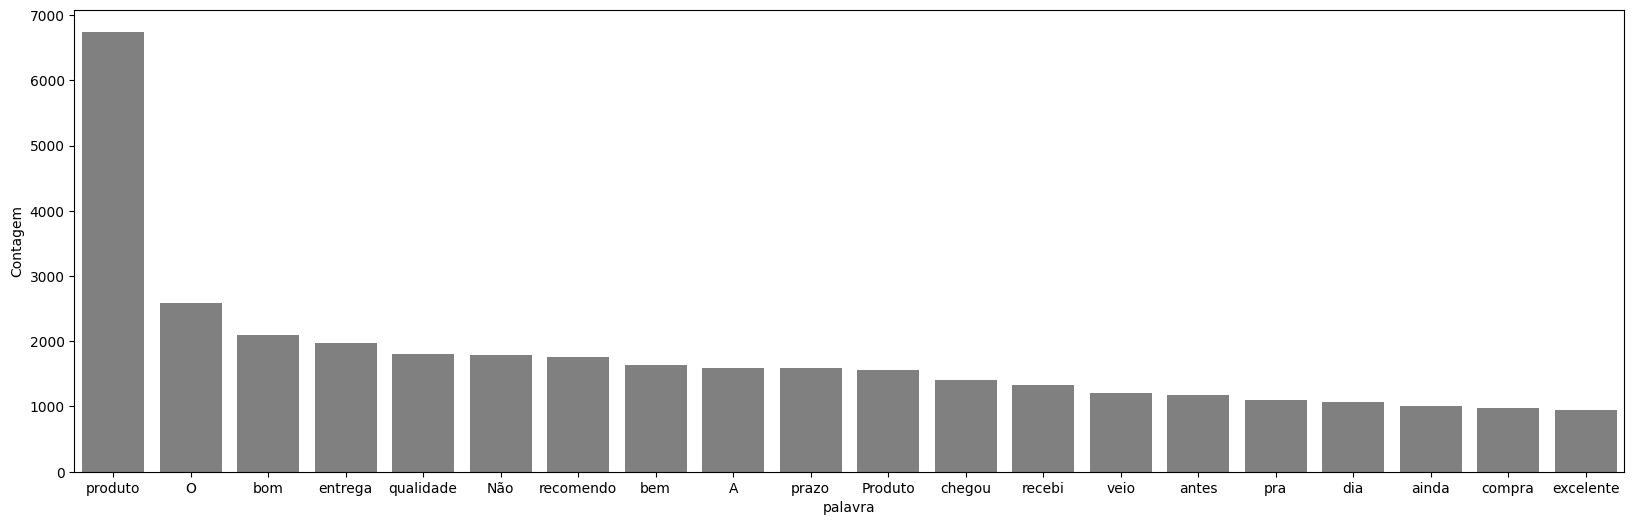

In [103]:
grafico_frequencia(dados,'tratamento_2',20)

In [104]:
! pip install unidecode

In [105]:
import unidecode

In [ ]:
sem_acento = [unidecode.unidecode(texto) for texto in dados['tratamento_2']]

In [147]:
stopwords_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [ ]:
# Algoritmo de filtragem de stopwords

def filtro_stopword_alfanumerico_sem_acento(df,nm_col_texto):
    
    sem_acento = [unidecode.unidecode(texto.lower()) for texto in df[nm_col_texto]] # Aplicando a uniformuzação do texto e removendo a acentuação da coluna antes da tokenização
    df[nm_col_texto] = sem_acento # Atruibuição da coluna sem acentuação
    palavras_irrelevantes =  nltk.corpus.stopwords.words('portuguese') # Definição das palavras irrelevantes da bilbioteca nlkt
    palavras_irrelevantes_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes] # Retirando a acentuacao das palavras irrelevantes
    palavras_processadas = [] # Lista vazia para armazenar o processamento da função
    token_pontuacao = tokenize.WordPunctTokenizer() # instancia do tokenizador que também separa em tokensm tudo que é alfánumérico incluíndo potuações

    for avaliacao in df[nm_col_texto]:
        token_palavras = token_pontuacao.tokenize(avaliacao) # Aplicação do tokem com base no espaço
        nova_frase = [palavra for palavra in token_palavras if palavra.isalpha() and palavra not in palavras_irrelevantes_sem_acento] # sub-laço for filtrando as palavras que não devem estar processamento final e eliminando os caracteres alfanuméricos
        palavras_processadas.append(' '.join(nova_frase)) # Append das palavras processadas
    
    return palavras_processadas # Retorno dos dados processados

In [166]:
dados['tratamento_3'] = filtro_stopword_alfanumerico_sem_acento(dados,'avaliacao')

In [170]:
dados['tratamento_4'] = filtro_stopword_alfanumerico_sem_acento(dados,'avaliacao')

In [164]:
dados['tratamento_2'][70]

'Melhor compra fiz ultimos tempos Produto barato util Produto robusto leve O teclado proporciona digitacao confortavel mouse preciso O teclado mouse usam apenas receptor economizando numero portas USB computador Me livrei incomodo fios espaco trabalho ficou limpo harmonioso Ademais tudo parece bastante duravel safisfeito Recomendo todos'

In [167]:
dados['tratamento_3'][70]

'Melhor compra fiz ultimos tempos Produto barato util Produto robusto leve O teclado proporciona digitacao confortavel mouse preciso O teclado mouse usam apenas receptor economizando numero portas USB computador Me livrei incomodo fios espaco trabalho ficou limpo harmonioso Ademais tudo parece bastante duravel safisfeito Recomendo todos'

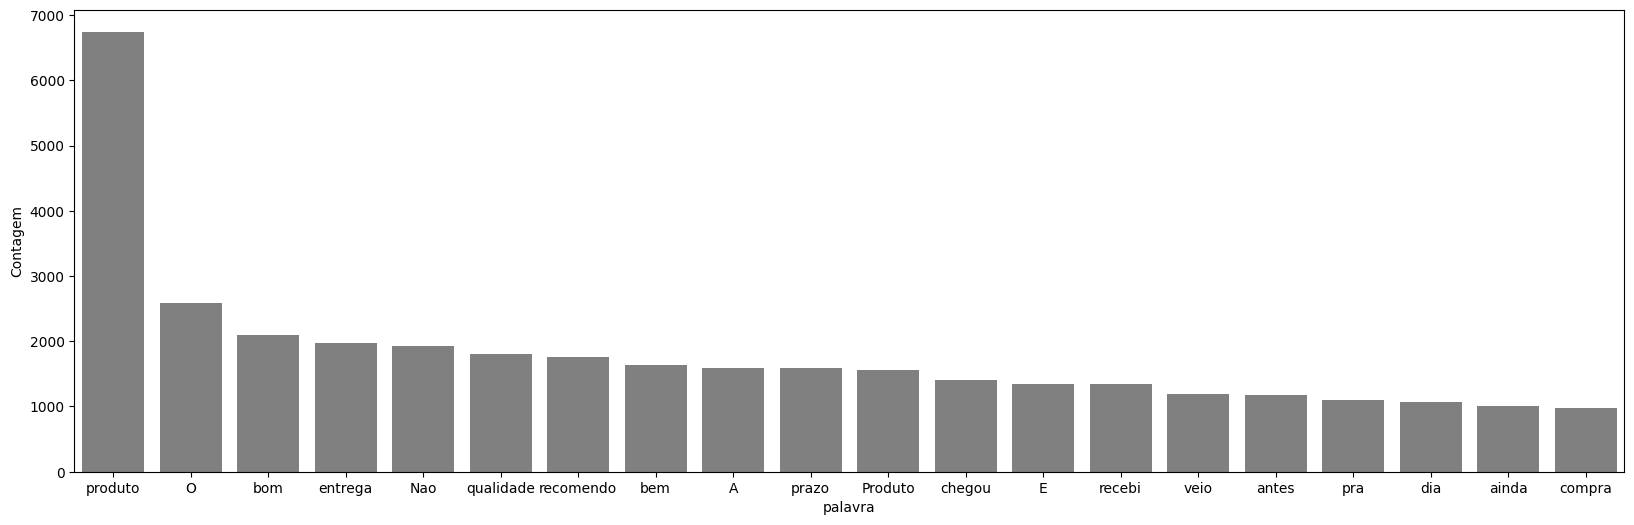

In [168]:
grafico_frequencia(dados, 'tratamento_3', 20)

In [172]:
dados['tratamento_3'][3]

'Atendeu expectativas achei luz ruim nada dificulte funcionamento'

In [173]:
dados['tratamento_4'][3]

'atendeu expectativas achei luz ruim nada dificulte funcionamento'

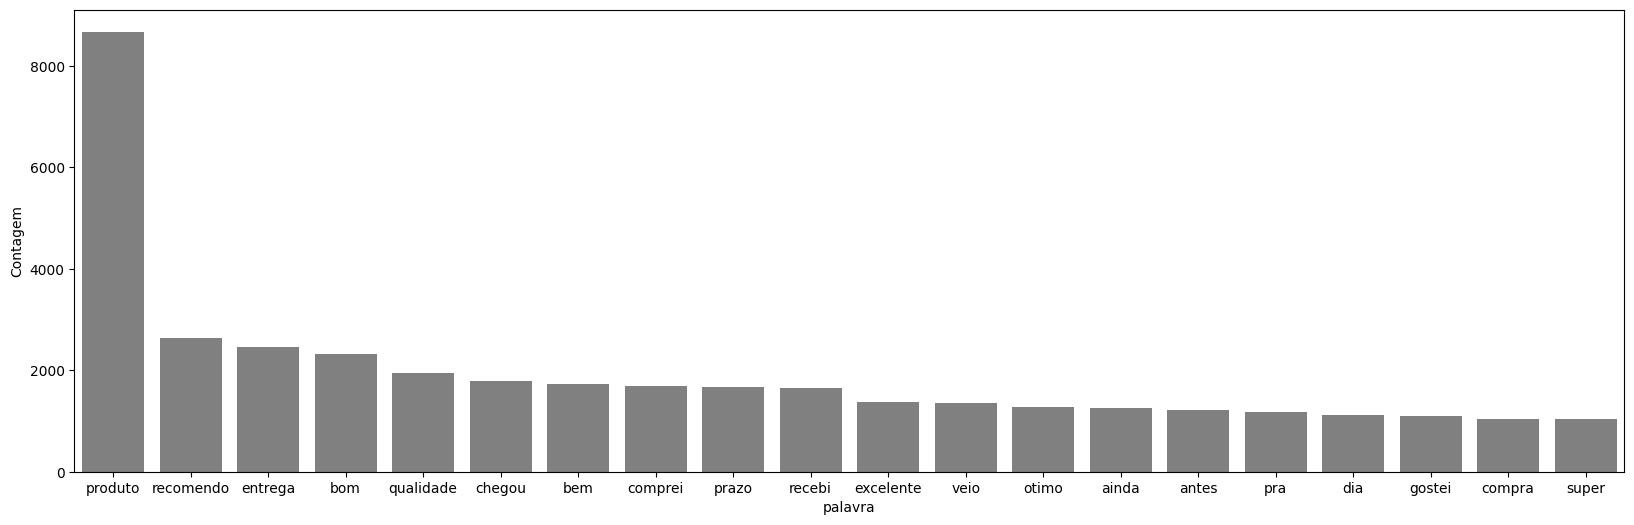

In [176]:
grafico_frequencia(dados, 'tratamento_4', 20)

In [179]:
classificar_texto(dados,'tratamento_1', 'sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_1': 81.09%


In [177]:
classificar_texto(dados,'tratamento_4', 'sentimento')

(15501, 50)

Acurácia do modelo com a coluna 'tratamento_4': 83.75%


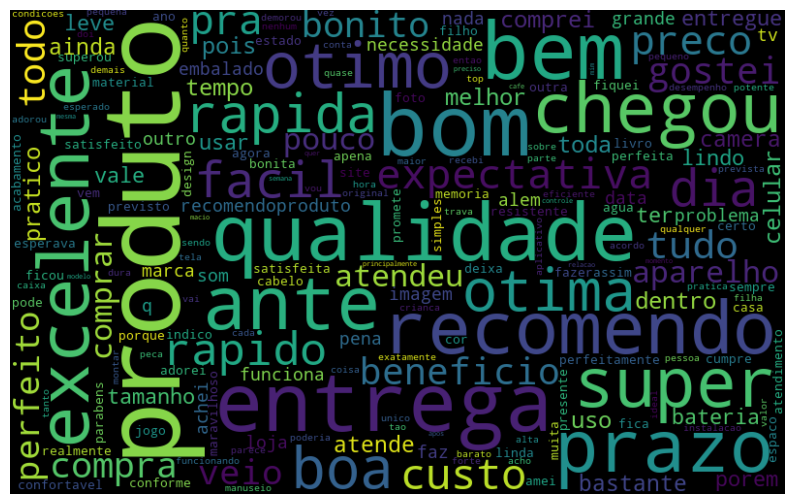

In [180]:
nuvem_palavras(dados,'tratamento_4','positivo')

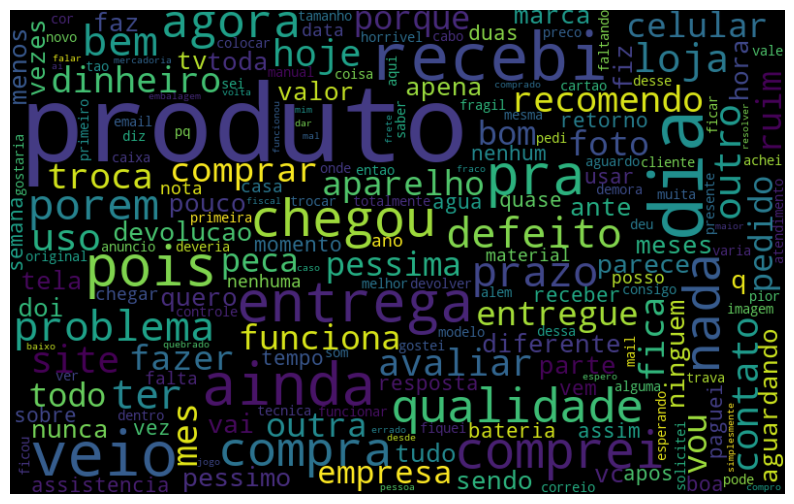

In [181]:
nuvem_palavras(dados,'tratamento_4','negativo')

- Importar uma lista de stopwords com a biblioteca NLTK;
- Realizar a tokenização por pontuação;
- Realizar o tratamento para remover a pontuação de um texto;
- Remover acentos com a biblioteca unidecode;
- Transformar todos os caracteres em minúsculo.